# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Maryam-Shile/flyrank_ml_internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*



## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

In [47]:
url = 'https://raw.githubusercontent.com/Maryam-Shile/flyrank_ml_internship/refs/heads/main/data/raw/content_refresh_anonymized.csv'
data = pd.read_csv(url)

data.head()


,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

In [73]:
def extract_clean(df):
  '''
  To keep this analysis robust, it is best to work with articles in the same peer group.
  This function creates, cleans and returns a dataset from the dataset passed as the argument of this function.
  The new dataset contains articles of the same type of content and intent, based on user input, and is ready for analysis.
  '''

  df['search_volume'] = df['search_volume'].replace(0, np.nan)
  df['competition'] = df['competition'].replace(0, np.nan)

  if 'avg_position' in df.columns:
        df['avg_position'] = pd.to_numeric(df['avg_position'], errors='coerce')
  df['avg_position'] = df['avg_position'].replace(0, np.nan)

  df_filtered = df[df['impressions_90d'] >= 100].copy()
  df_filtered['search_volume_log'] = np.log10(df['search_volume'] + 1)

  #density or penetration score
  opportunity_index = 1 - df_filtered['competition'] * df_filtered['search_volume_log']
  df_filtered['opportunity_score'] = df_filtered['search_volume_log'] * opportunity_index

  print(f'This dataset contains main intent of the following: {df_filtered['main_intent'].unique()}')
  main_intent = input("Please enter the main intent: ")

  print(f'This dataset contains content types of the following: {df_filtered['content_type'].unique()}')
  content_type = input("Please enter the content type: ")

  print('')

  df_new = df_filtered[(df_filtered['main_intent'] == main_intent) & (df_filtered['content_type'] == content_type)].copy()

  to_drop = []

  for i in df_new.columns:
    if 'tier' in i:
      to_drop.append(i)

  df_new = df_new.drop(columns = to_drop, axis = 1)

  if df_new.empty:
    print(f'Your selection has no data')

  else:
    performance_columns = ['impressions_90d',
       'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d',
       'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
       'days_with_impressions', 'days_with_sessions', 'impressions_last_30d',
       'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d',
       'clicks_prev_30d', 'sessions_prev_30d','ctr', 'avg_position', 'engagement_rate',
       'scroll_rate', 'ai_traffic_pct', 'trend_direction', 'trend_pct']

  performance_data = df_new[performance_columns]

  for i in performance_data.columns:
    if '30d' in i:
      performance_data = performance_data.drop(columns = [i], axis = 1)

  performance_data = performance_data.drop(columns = ['sessions_90d', 'users_90d'], axis = 1)

  performance_columns = list(performance_data)
  content_data_columns = ['cpc', 'content_type',
                        'main_intent', 'word_count',
                        'char_count', 'provider_used', 'model_used',
                        'content_age_days','days_since_last_update']

  environment_columns = ['search_volume', 'competition', 'opportunity_score']

  final_columns = content_data_columns + performance_columns + environment_columns

  final_data = df_new[final_columns].copy()

  print(f'Filtering and cleaning for {main_intent} and {content_type} articles successful. Your new dataset is ready for use')

  return final_data



In [79]:
def compute_performance_score(df):

  higher = ['impressions_90d', 'clicks_90d', 'pageviews_90d',
       'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
       'days_with_impressions', 'days_with_sessions', 'ctr', 'engagement_rate',
          'scroll_rate', 'ai_traffic_pct']
  lower = ['avg_position']

  for i in higher:
    name = i + '_rank'
    df[name] = df[i].rank(pct = True)

  for j in lower:
    name = j + '_rank'
    df[name] = (-df[j]).rank(pct = True)

  performance_metrics = []
  for i in df.columns:
    if 'rank' in i:
      performance_metrics.append(i)

  df['performance_score'] = df[performance_metrics].sum(axis = 1) * 100 / len(performance_metrics)
  df.drop(columns = higher+lower, axis = 1, inplace = True)

  print('Performance score computed for each row, check column - performance_score')
  return df


In [74]:
info_data = extract_clean(data)

This dataset contains main intent of the following: ['transactional' 'informational' 'commercial' nan 'navigational']
Please enter the main intent: informational
This dataset contains content types of the following: ['keyword article' 'comparison article' 'feedly article']
Please enter the content type: keyword article

Filtering and cleaning for informational and keyword article articles successful. Your new dataset is ready for use


In [75]:
info_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12844 entries, 1 to 29996
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   cpc                     12715 non-null  float64
 1   content_type            12844 non-null  object 
 2   main_intent             12844 non-null  object 
 3   word_count              9453 non-null   float64
 4   char_count              9453 non-null   float64
 5   provider_used           3975 non-null   object 
 6   model_used              10278 non-null  object 
 7   content_age_days        12844 non-null  int64  
 8   days_since_last_update  12844 non-null  int64  
 9   impressions_90d         12844 non-null  int64  
 10  clicks_90d              12844 non-null  int64  
 11  pageviews_90d           12844 non-null  int64  
 12  engaged_sessions_90d    12844 non-null  int64  
 13  ai_sessions_90d         12844 non-null  int64  
 14  scroll_events_90d       12844 non-null  int

In [80]:
info_data = compute_performance_score(info_data)
info_data

Performance score computed for each row, check column - performance_score


,cpc,content_type,main_intent,word_count,char_count,provider_used,model_used,content_age_days,days_since_last_update,trend_direction,...,engaged_sessions_90d_rank,ai_sessions_90d_rank,scroll_events_90d_rank,days_with_impressions_rank,days_with_sessions_rank,ctr_rank,engagement_rate_rank,scroll_rate_rank,ai_traffic_pct_rank,avg_position_rank
1,0.05,keyword article,informational,2481.0,15562.0,NaN,gemini-3-flash-preview,445,25,down,...,0.316296,0.458852,0.440011,0.744978,0.477344,0.322096,0.316296,0.658740,0.458852,0.328402
2,0.00,keyword article,informational,3515.0,23643.0,NaN,gemini-2.5-flash,141,20,down,...,0.316296,0.458852,0.735207,0.744978,0.536904,0.400420,0.316296,0.854280,0.458852,0.106898
4,0.00,keyword article,informational,2803.0,17469.0,NaN,gemini-3-flash-preview,263,14,down,...,0.316296,0.458852,0.981236,0.744978,0.833463,0.480769,0.316296,0.819507,0.458852,0.063921
8,0.00,keyword article,informational,3807.0,24228.0,google,gemini-3-flash-preview,90,20,down,...,0.916031,0.458852,0.843779,0.336188,0.893102,0.400420,0.861414,0.560190,0.458852,0.056486
9,0.00,keyword article,informational,NaN,NaN,NaN,NaN,257,104,down,...,0.316296,0.458852,0.168678,0.744978,0.180162,0.537060,0.316296,0.168915,0.458852,0.906960
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29984,0.00,keyword article,informational,5962.0,38349.0,NaN,gemini-3-flash-preview,229,104,down,...,0.718117,0.931330,0.440011,0.744978,0.735752,0.617175,0.669184,0.339973,0.943709,0.523669
29985,0.00,keyword article,informational,2666.0,19294.0,google,gemini-3-flash-preview,139,20,stable,...,0.916031,0.458852,0.735207,0.744978,0.902600,0.936663,0.813648,0.475791,0.458852,0.788462
29989,0.00,keyword article,informational,NaN,NaN,NaN,NaN,148,104,down,...,0.836811,0.458852,0.594363,0.744978,0.709670,0.322096,0.909841,0.603540,0.458852,0.833268
29990,0.00,keyword article,informational,2501.0,15617.0,NaN,gemini-3-flash-preview,280,14,stable,...,0.316296,0.458852,0.168678,0.744978,0.355380,0.537060,0.316296,0.168915,0.458852,0.287060


In [81]:
info_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12844 entries, 1 to 29996
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cpc                         12715 non-null  float64
 1   content_type                12844 non-null  object 
 2   main_intent                 12844 non-null  object 
 3   word_count                  9453 non-null   float64
 4   char_count                  9453 non-null   float64
 5   provider_used               3975 non-null   object 
 6   model_used                  10278 non-null  object 
 7   content_age_days            12844 non-null  int64  
 8   days_since_last_update      12844 non-null  int64  
 9   trend_direction             12844 non-null  object 
 10  trend_pct                   12767 non-null  float64
 11  search_volume               5764 non-null   float64
 12  competition                 3567 non-null   float64
 13  opportunity_score           3567 non

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [53]:
def plot_performance(df):

    num_cols = list(df.select_dtypes(include=['number']).columns)
    cat_cols = list(df.select_dtypes(exclude=['number']).columns)

    for i in num_cols:
      ax = df.plot(
      kind="scatter",
      x="performance_score",
      y=i,
      alpha=0.5,  # Makes overlapping points transparent so you can see density
      title= f"Performance x {i}",
      figsize=(10, 6),
      )

    # Use log scale if high-volume outliers compress your chart
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()
    print ('')
    print('')

    return

In [82]:
baseline = info_data[info_data['trend_direction'] == 'down'].copy()
baseline['performance_score'] = info_data.performance_score
baseline.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7769 entries, 1 to 29996
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cpc                         7722 non-null   float64
 1   content_type                7769 non-null   object 
 2   main_intent                 7769 non-null   object 
 3   word_count                  6242 non-null   float64
 4   char_count                  6242 non-null   float64
 5   provider_used               2664 non-null   object 
 6   model_used                  6613 non-null   object 
 7   content_age_days            7769 non-null   int64  
 8   days_since_last_update      7769 non-null   int64  
 9   trend_direction             7769 non-null   object 
 10  trend_pct                   7769 non-null   float64
 11  search_volume               3049 non-null   float64
 12  competition                 1944 non-null   float64
 13  opportunity_score           1944 non-

/usr/local/lib/python3.13/dist-packages/pandas/plotting/_matplotlib/core.py:580: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = self.plt.figure(figsize=self.figsize)


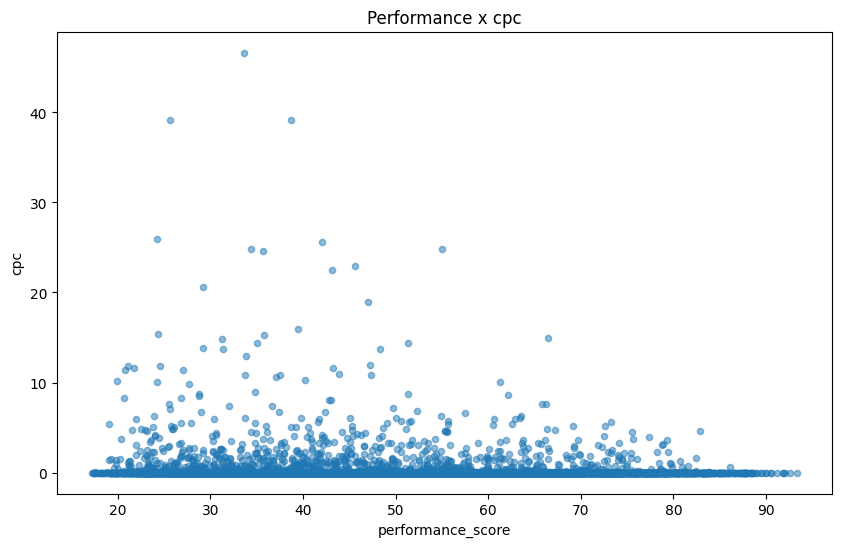

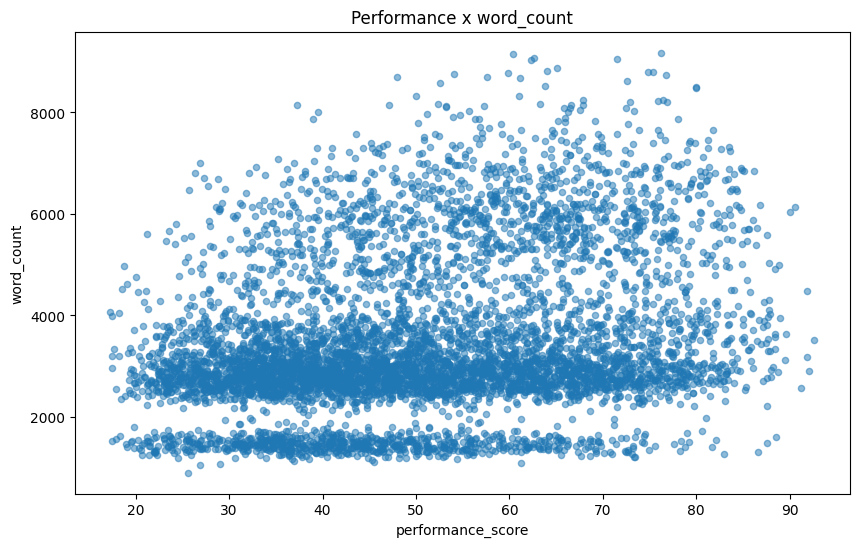

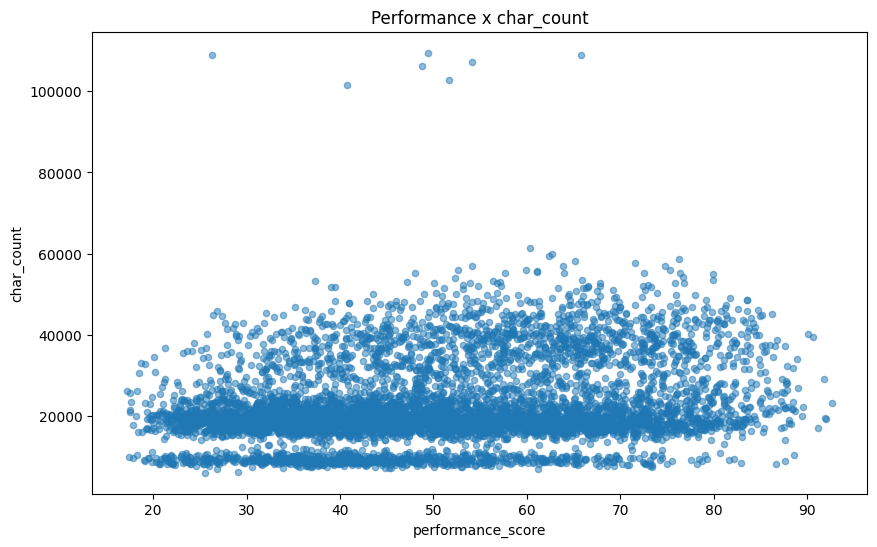

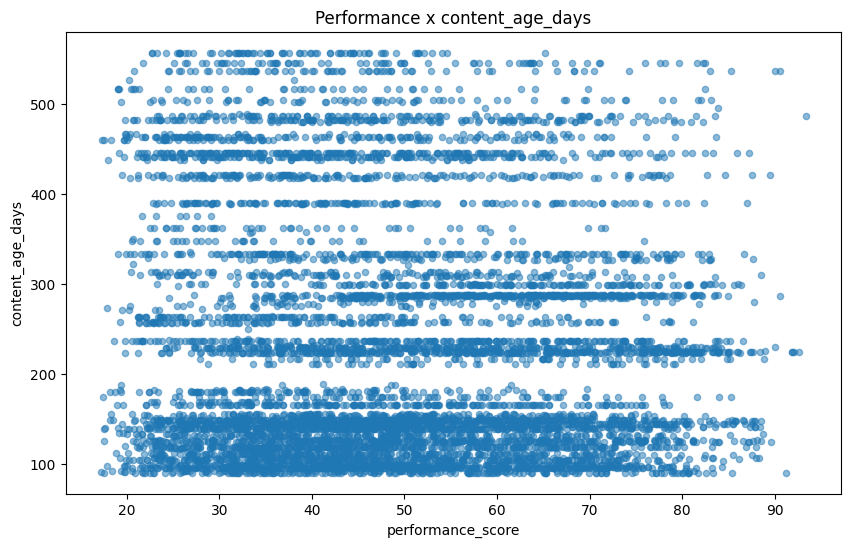

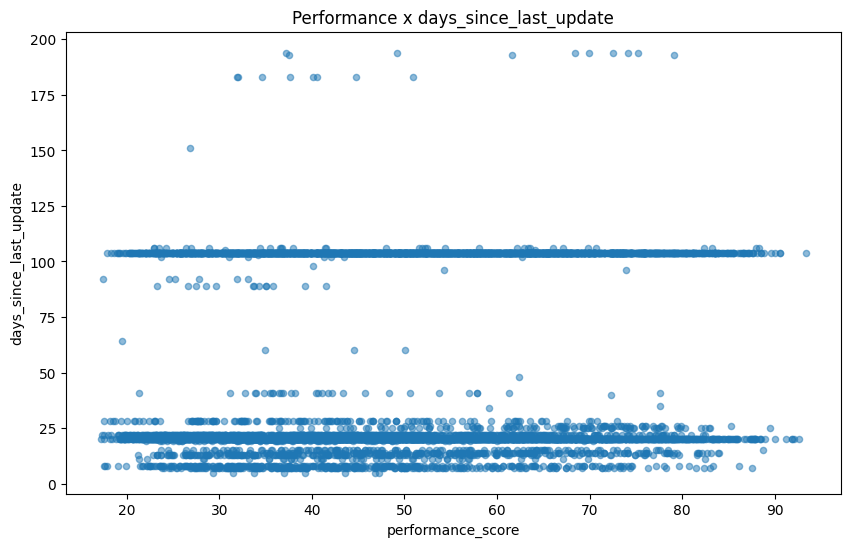

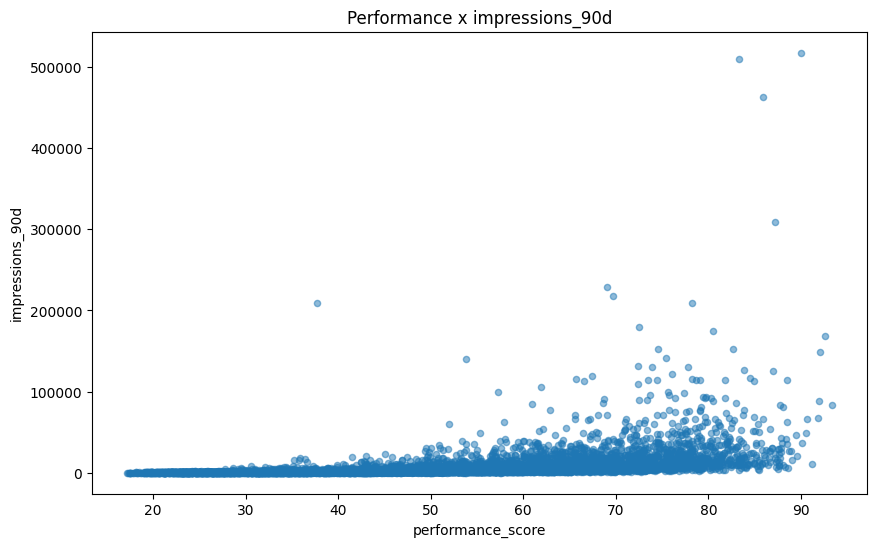

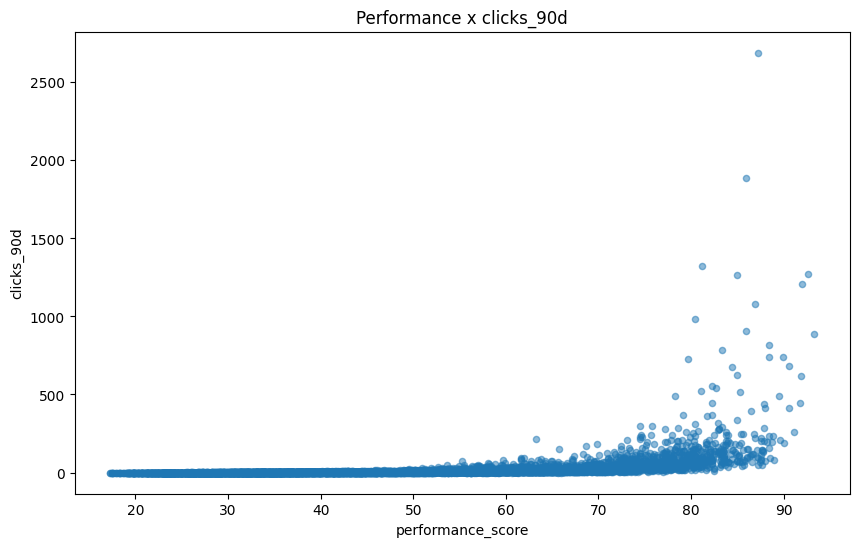

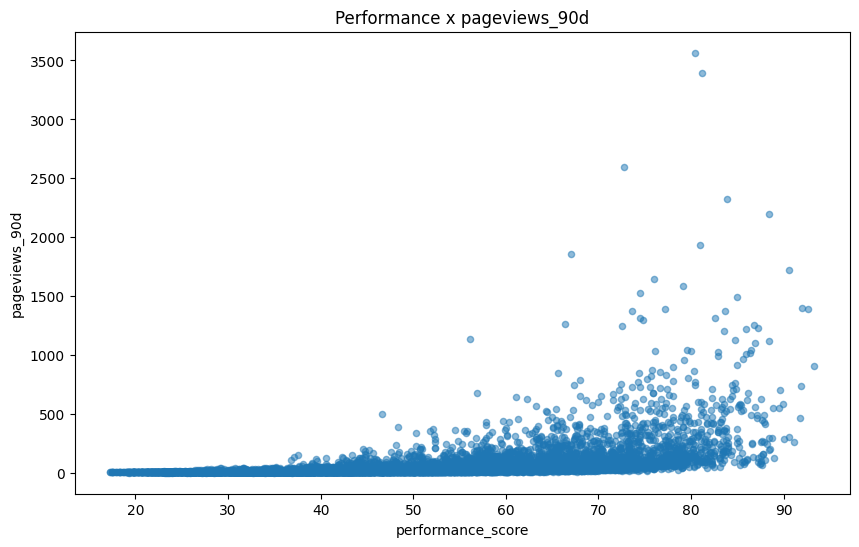

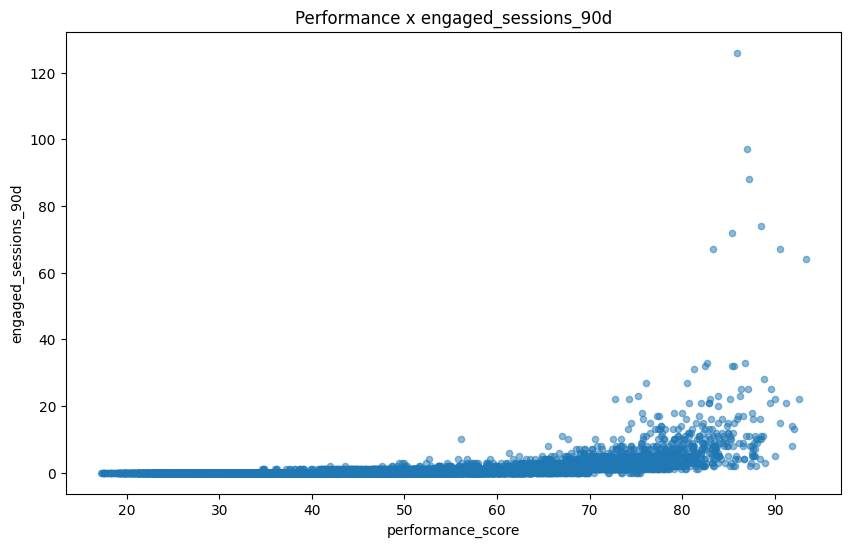

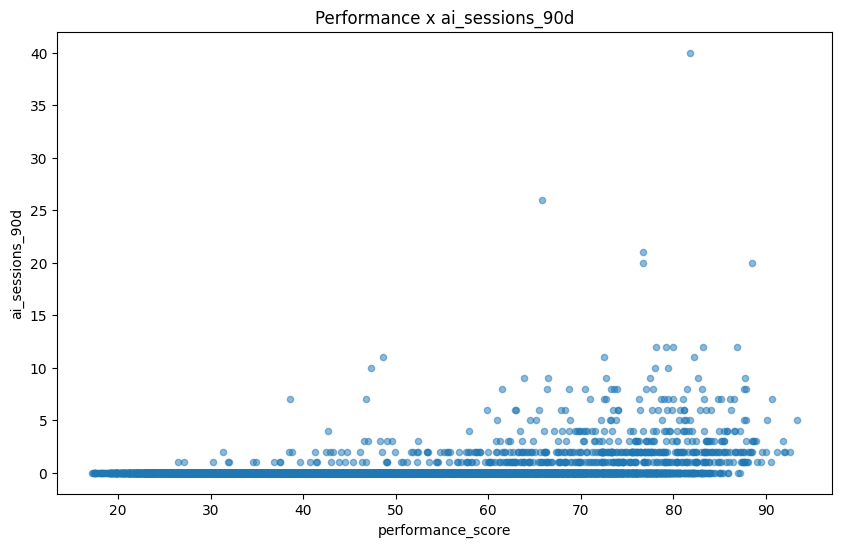

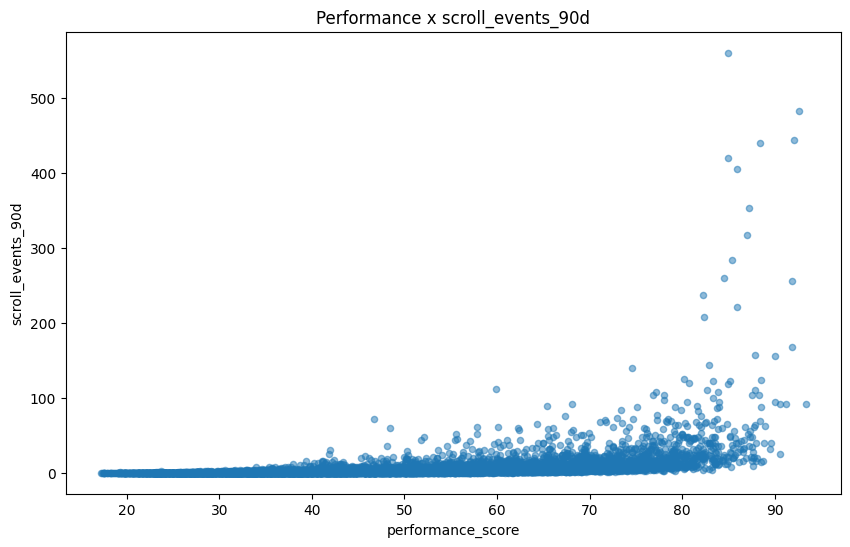

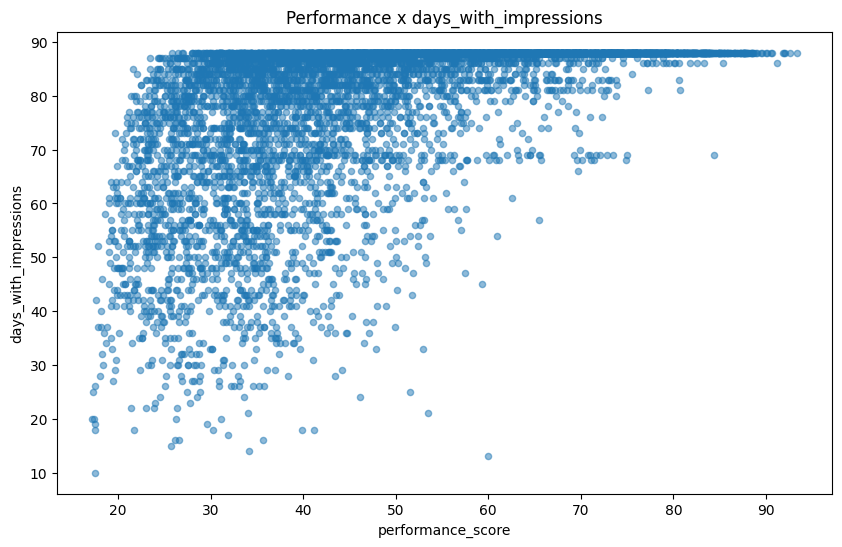

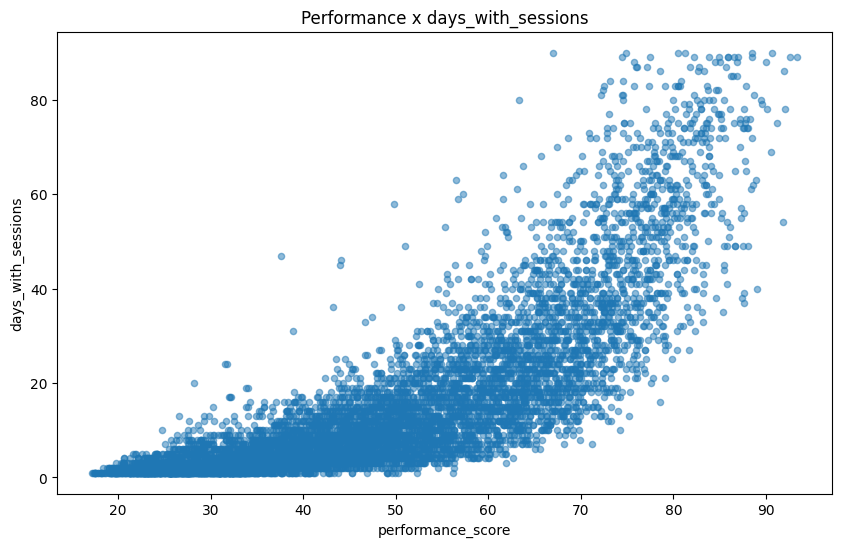

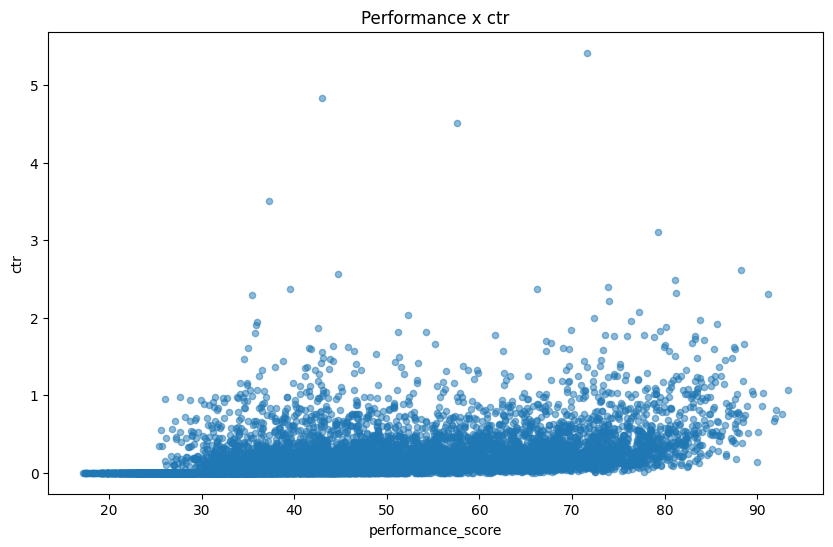

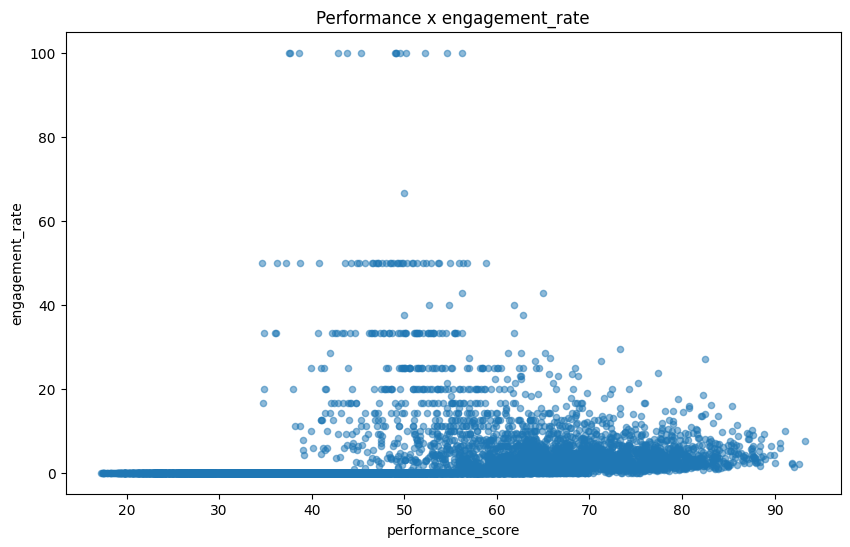

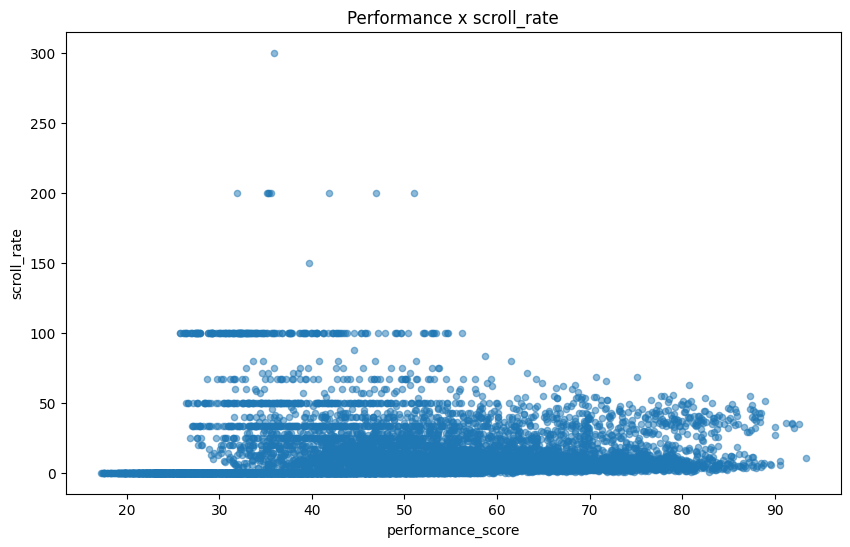

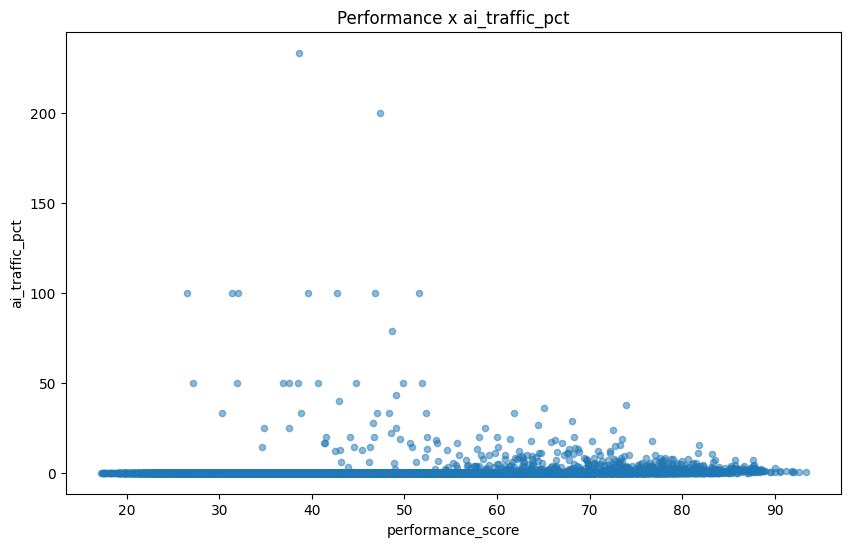

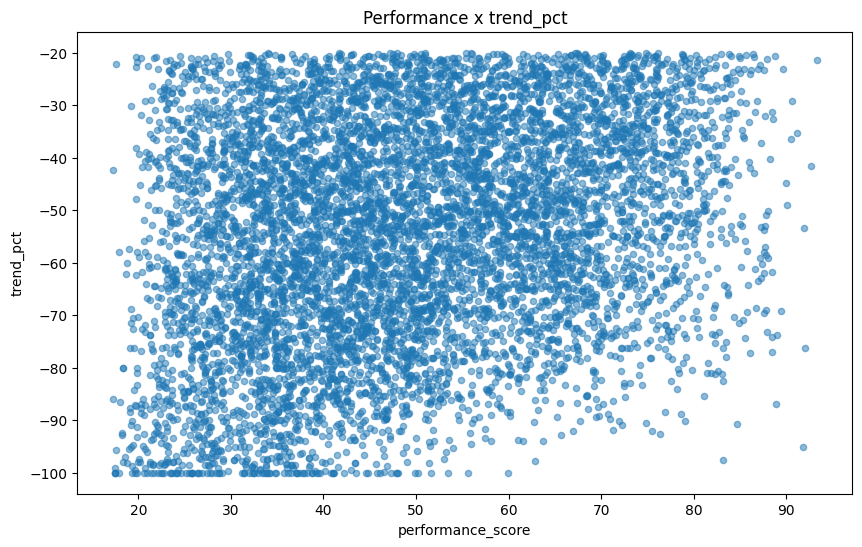

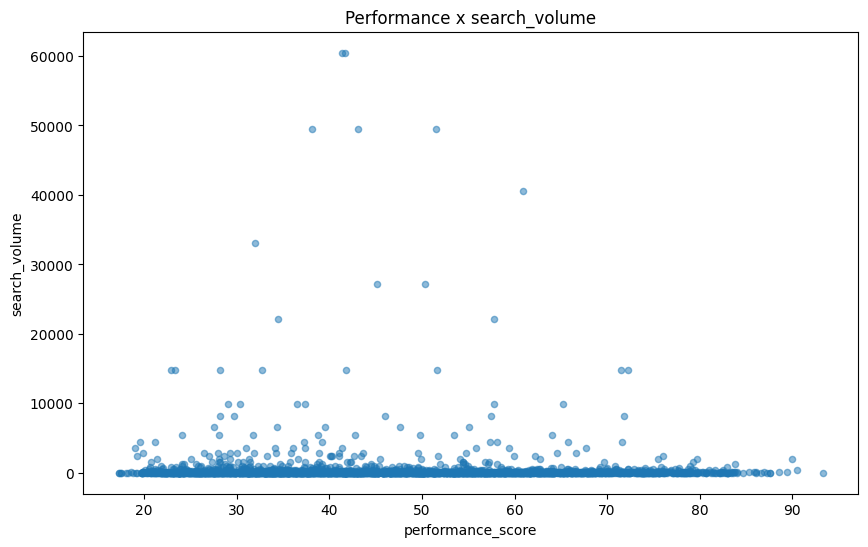

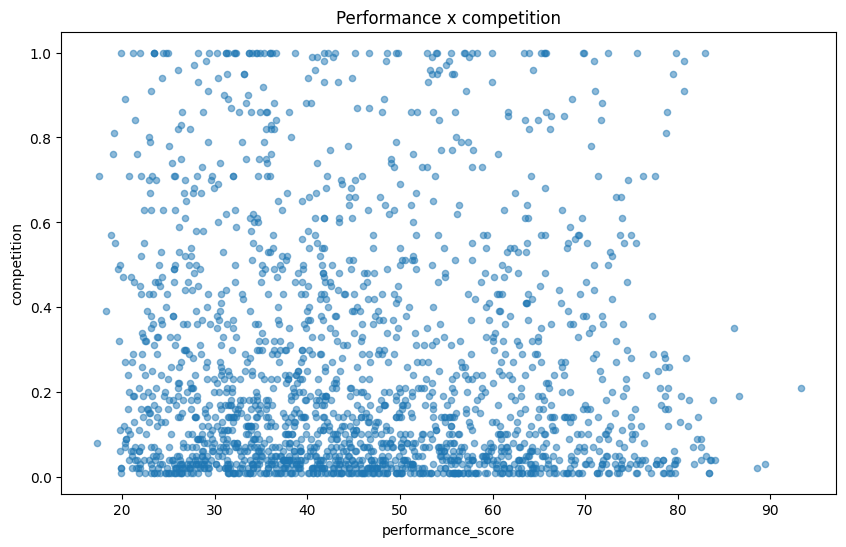

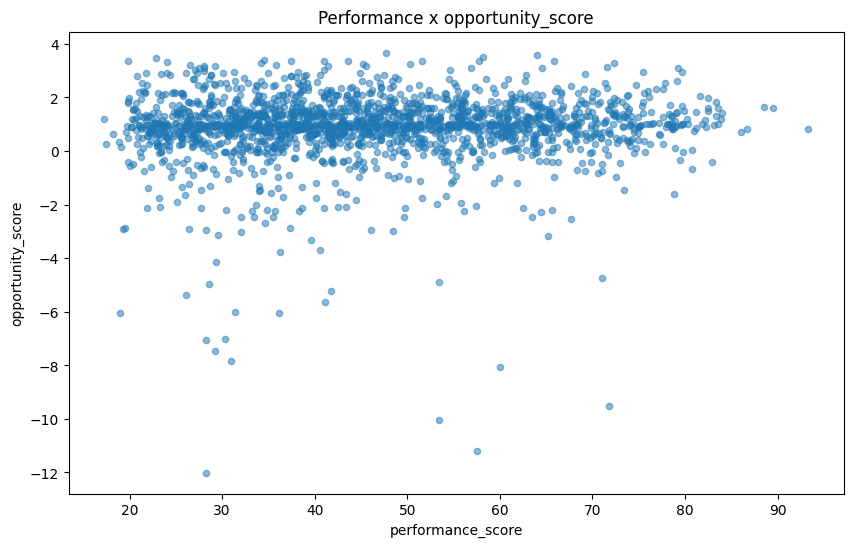

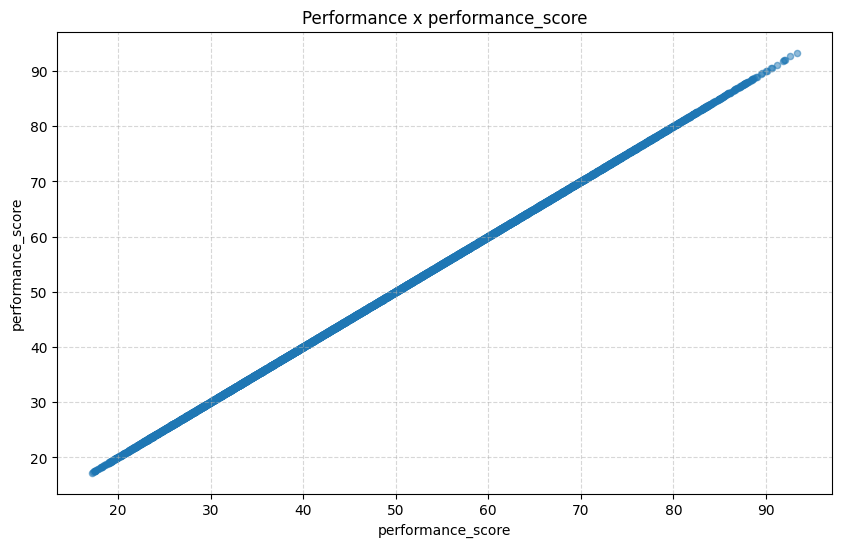

In [56]:
plot_performance(baseline)

In [83]:
def plot_elbow(df):
    df = df.copy()
    to_drop = ['provider_used', 'model_used', 'content_type', 'main_intent', 'trend_direction', 'trend_pct', 'word_count']
    df = df.drop(columns = to_drop, axis = 1)
    # 2. Make sure ALL metadata / ID / content columns are included here

    content_cols = ['char_count', 'content_age_days', 'days_since_last_update']

    df_performance = df.drop(columns=content_cols, errors='ignore')

    # 3. Select features (content_id is now safely excluded)
    perf_num_cols = list(df_performance.select_dtypes(include=['number']).columns)
    perf_cat_cols = list(df_performance.select_dtypes(exclude=['number']).columns)

    num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    perf_num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])

    cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num_pipeline', num_pipeline, content_cols),
            ('perf_num_pipeline', perf_num_pipeline, perf_num_cols),
            ('cat_pipeline', cat_pipeline, perf_cat_cols)
        ],
        sparse_threshold=0
    )

    processed_data = preprocessor.fit_transform(df)

    # 4. Fit KMeans & Plot
    inertia = []
    k_range = range(1, 10)

    for i in k_range:
        kmeans = KMeans(n_clusters=i, random_state=42, n_init='auto')
        kmeans.fit(processed_data)
        inertia.append(kmeans.inertia_)

    plt.plot(k_range, inertia, '-o')
    plt.xlabel('Number of clusters')
    plt.ylabel('Inertia')
    plt.xticks(k_range)
    plt.show()

    return

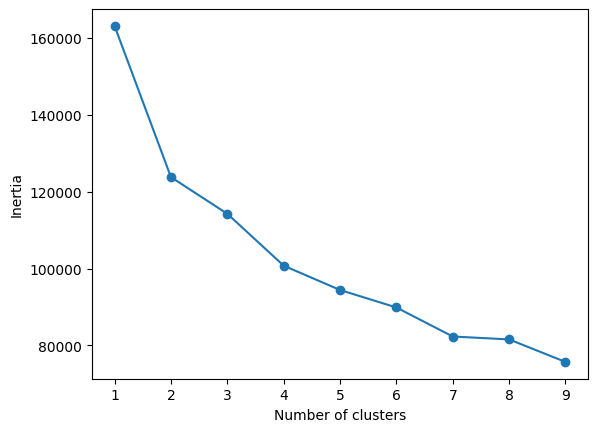

In [84]:
plot_elbow(baseline)

## 5. Limitations

*What this work cannot claim.*

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
